# Cell envelope: Phenotype Prediction, Feature Selection, and Exploration of Phenotypic Signal Distribution

This notebook provides a pipeline for predicting microbial oxygen-use phenotypes from genomic data and identifying the genomic features associated with these phenotypes.

We train and evaluate an XGBoost classifier using COG count tables. Genomes are split into training and test sets at a specified taxonomic level, such that all genomes belonging to a given taxonomic group are assigned exclusively to either the training or the test set. The notebook is designed to be run for a single taxonomic-level split at a time.

To identify genomic footprints and the most informative COGs contributing to phenotype prediction, we employ two complementary feature-selection approaches:

- SHAP values, computed from the trained XGBoost model (model-dependent feature importance);
- Markov blanket discovery, a model-agnostic method for identifying features that contain information about the phenotype.

To investigate how phenotypic information is distributed across the genome, we retrain and evaluate models on progressively larger and smaller feature subsets ranked by SHAP importance. This analysis reveals whether predictive signal is concentrated in a small number of features or distributed across many genomic traits.

### 1. Read train/test datasets

First, we read the input files generated by *taxa_level_split.py*. The script generates 6 output files for the chosen [tax_level] of the train/test split, that are used as main inputs in this notebook. The files are the following:

- train_data_[tax_level]_tax_level : training count table,
- train_annot_[tax_level]_tax_level : training annotations,
- train_taxa_names_[tax_level]_tax_level : [tax_level] name of each training sample,

\+ 3 similar test tables. Those files should be stored in the corresponding directory for the phenotype.

In order to run the phenotype prediction pipeline in this notebook, the data directory with the input files, and [tax_level] of the train/test split should be specified below.

In [31]:
import pandas as pd
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils.utils import read_diderm_data, pca_run_and_plot, tsne_plot

TAX_LEVEL = "phylum" # <----------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_diderm"  # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Create the output directory if doesn't exist
if not os.path.exists(OUTPUT_DIRECTORY):
    os.makedirs(OUTPUT_DIRECTORY)

In [3]:
# Read train/test splits

from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_train, y_label_train, X_column_names, taxa_group_names_train, genome_accesion_train = read_diderm_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE, return_genome_accession = True)
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_test, y_label_test, X_column_names, taxa_group_names_test, genome_accesion_test = read_diderm_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE, return_genome_accession = True)

    if sum(y_label_test) == 0 or sum(y_label_train) == 0:
        continue

    if TAX_LEVEL == "random":
        taxa_group_names_train = None
        taxa_group_names_test = None
        
    curr_split_dict = defaultdict(str)
    curr_split_dict["X_train"] = X_val_train
    curr_split_dict["y_train"] = y_label_train
    curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
    curr_split_dict["genome_accesion_train"] = genome_accesion_train
    
    curr_split_dict["X_test"] = X_val_test
    curr_split_dict["y_test"] = y_label_test
    curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    curr_split_dict["feature_names"] = X_column_names
    curr_split_dict["genome_accesion_test"] = genome_accesion_test
    
    all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")    

Number of added splits = 30


In [4]:
# Concatenate train and test for the 2D visualization
y_label = torch.cat((y_label_train, y_label_test), dim=0)
X_val = torch.cat((X_val_train, X_val_test), dim=0)
if TAX_LEVEL != "random":
    taxa_group_names = taxa_group_names_train + taxa_group_names_test
else:    
    taxa_group_names = None

### 2. Data visualization

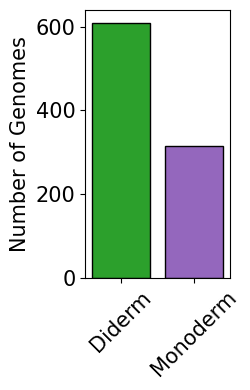

In [5]:
from matplotlib.colors import ListedColormap

# A histogram of data labels distribution

FONTSIZE = 15

labels = ['Diderm', 'Monoderm']

num_aerobs = sum(y_label.cpu()).item()
num_anaerobs = len(y_label.cpu()) - sum(y_label.cpu()).item()
values = [num_anaerobs, num_aerobs]

# Plot
plt.figure(figsize=(2.5,4))
bars = plt.bar(labels, values, color=["tab:green", "tab:purple"], width=0.8, edgecolor='black')
plt.xticks(rotation=45, fontsize = FONTSIZE) 
plt.ylabel("Number of Genomes", fontsize=FONTSIZE)
#plt.ylim(0, 1)
plt.yticks([0, 200, 400, 600], fontsize = FONTSIZE)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/data_distrib.svg", format="svg")

We visualize all points from our datasets by projecting them into 2D tSNE space. This projections give us insights on the structure of the datasets. One point = one sample/genome.

We color the projected samples with respect to their phenotype, and their taxonomy specified by TAX_LEVEL.

Shape of the projected data = (926, 2)


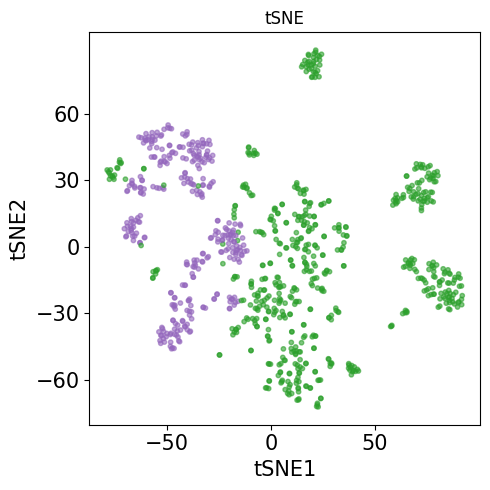

In [6]:
# tSNE plot: colors = phenotype

plt.figure(figsize=(5,5))

colors = ListedColormap(["tab:green", "tab:purple"])

tsne_plot(X_val.cpu(), 10, 30, RANDOM_SEED, y_label.cpu(), colors, s = 10);
plt.xlabel("tSNE1", fontsize = FONTSIZE)
plt.ylabel("tSNE2", fontsize = FONTSIZE)
plt.xticks([-50, 0, 50], fontsize = FONTSIZE)
plt.yticks([-60, -30, 0, 30, 60], fontsize = FONTSIZE)

# Display the plots
plt.tight_layout()  
plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tsne_orig_phenot.svg", format="svg")
plt.show()

Shape of the projected data = (926, 2)


<Figure size 500x500 with 0 Axes>

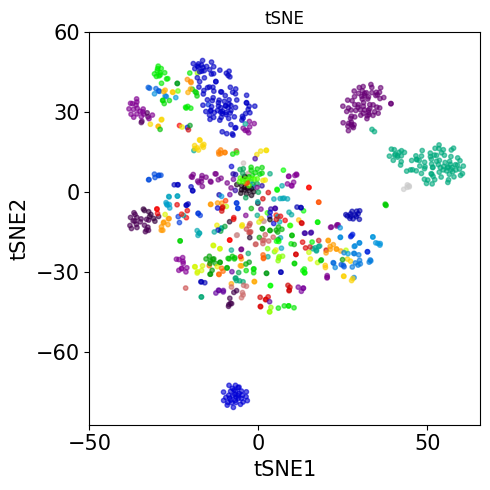

In [7]:
# tSNE plot: colors = taxonomy defined by TAX_LEVEL

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

plt.figure(figsize=(5,5))
if TAX_LEVEL != "random":  
    plt.figure(figsize=(5,5))
    tsne_plot(X_val.cpu(), 30, 100, RANDOM_SEED, label_encoder.fit_transform(taxa_group_names), None);
    plt.xlabel("tSNE1", fontsize = FONTSIZE)
    plt.ylabel("tSNE2", fontsize = FONTSIZE)
    plt.xticks([-50, 0, 50], fontsize = FONTSIZE)
    plt.yticks([-60, -30, 0, 30, 60], fontsize = FONTSIZE)
    plt.tight_layout()  
    plt.savefig(f"{OUTPUT_DIRECTORY}/pca_tse_orig_phylogen.svg", format="svg")
    plt.show();

### 3. XGBoost training and testing

In this section we train XGBoost classifier for the phenotype prediction, and perform the feature selection analysisc based on three different methods.

First, we find the baseline (for all GOGs) test and cross-validation accuracy measures. As the accuracy measures, we use the following:

- accuracy = $\frac{TP+TN}{TP+TN+FP+FN}$,
- precision = $\frac{TP}{TP+FP}$,
- recall = $\frac{TP}{TP+FN}$,
- F1 = $2 \frac{precision \times recall}{precision + recall}$.

In [8]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
from feature_selection.feature_selection_utils import xgboost_train_accur

cv_accur_dict_splits = defaultdict(list)
test_accur_dict_splits = defaultdict(list)
test_accur_dict_splits_baseline = defaultdict(list)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

    for split_id in all_splits_dict.keys():
        print(f"Processing {split_id} split...")
        X_val_train = all_splits_dict[split_id]["X_train"]
        y_label_train = all_splits_dict[split_id]["y_train"]
        X_val_test = all_splits_dict[split_id]["X_test"]
        y_label_test = all_splits_dict[split_id]["y_test"]
        if sum(y_label_train) == 0 or sum(y_label_test) == 0:
            continue
    
        taxa_group_names_train = all_splits_dict[split_id]["taxa_group_names_train"]
    
        cv_accuracy_scores, test_accuracy_scores = xgboost_train_accur(X_val_train, y_label_train, X_val_test, y_label_test, DEVICE, groups = taxa_group_names_train)
        for accur_measure in cv_accuracy_scores.keys():
            cv_accur_dict_splits[accur_measure].append(cv_accuracy_scores[accur_measure])
            test_accur_dict_splits[accur_measure].append(test_accuracy_scores[accur_measure])
            
        #Calculate the baseline accuracies
        N_tot = len(y_label_test)
        N_1 = sum(y_label_test).item()
        N_0 = N_tot - N_1
        fp = tn = N_0/2
        tp = fn = N_1/2
    
        if tp+fn >0:
            pres = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*(pres*recall)/(pres+recall)
            mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
        
            test_accur_dict_splits_baseline["accuracy"].append((tp+tn)/N_tot)
            test_accur_dict_splits_baseline["balanced_accuracy"].append(0.5)
            test_accur_dict_splits_baseline["precision"].append(pres)
            test_accur_dict_splits_baseline["recall"].append(recall)
            test_accur_dict_splits_baseline["f1"].append(f1)
            test_accur_dict_splits_baseline["roc_auc"].append(0)
            test_accur_dict_splits_baseline["mcc"].append(mcc)

cv_accur_dict_mean = defaultdict(float)
cv_accur_dict_std = defaultdict(float)
test_accur_dict_mean = defaultdict(float)
test_accur_dict_std = defaultdict(float)
test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)

for accur_measure in cv_accur_dict_splits.keys():
    
    cv_accur_dict_mean[accur_measure] = np.mean(cv_accur_dict_splits[accur_measure])
    cv_accur_dict_std[accur_measure] = np.std(cv_accur_dict_splits[accur_measure])
    
    test_accur_dict_mean[accur_measure] = np.mean(test_accur_dict_splits[accur_measure])
    test_accur_dict_std[accur_measure] = np.std(test_accur_dict_splits[accur_measure])

    test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])

/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing 0 split...
Processing 1 split...
Processing 2 split...
Processing 3 split...
Processing 4 split...
Processing 5 split...
Processing 6 split...
Processing 7 split...
Processing 8 split...
Processing 9 split...
Processing 10 split...
Processing 11 split...
Processing 12 split...
Processing 13 split...
Processing 14 split...
Processing 15 split...
Processing 16 split...
Processing 17 split...
Processing 18 split...
Processing 19 split...
Processing 20 split...
Processing 21 split...
Processing 22 split...
Processing 23 split...
Processing 24 split...
Processing 25 split...
Processing 26 split...
Processing 27 split...
Processing 28 split...
Processing 29 split...


/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/flash/SzollosiU/anzhelika-koldaeva/gene-context/mlm/pytorch_3.11/lib/python3.11/site-packages/numpy

In [9]:
metrics = {"cv mean"           : cv_accur_dict_mean, \
           "cv std"            : cv_accur_dict_std, \
           "test mean"         : test_accur_dict_mean, \
           "test std"          : test_accur_dict_std, \
           "test baseline mean": test_accur_dict_splits_baseline_mean, \
           "test baseline std" : test_accur_dict_splits_baseline_std} 

df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['balanced_accuracy','accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'ece'])

# Save the results
df.to_csv(f"{OUTPUT_DIRECTORY}/model_metrics.csv")

df

,cv mean,cv std,test mean,test std,test baseline mean,test baseline std
balanced_accuracy,0.989357,0.007211,0.994414,0.005955,0.500000,0.000000
accuracy,0.987183,0.006670,0.992695,0.007708,0.500000,0.000000
precision,0.969101,0.011343,0.970893,0.038887,0.344263,0.167516
recall,0.995296,0.012386,0.998292,0.006418,0.500000,0.000000
f1,0.981380,0.009663,0.983960,0.020487,0.383517,0.124603
mcc,0.972348,0.013859,0.978683,0.023593,0.000000,0.000000
roc_auc,NaN,NaN,NaN,NaN,NaN,NaN
ece,0.019784,0.005789,0.015608,0.009919,NaN,NaN


### 4. Phylogeny based predictions

#### 4.1. Phylogeny agreement

In this section we find the phenotype agreement across taxonomy groups for each taxonomy level.

In [10]:
# Read a phenotype annotation file
all_gene_annot = "../data_diderm/gold_standard1.tsv"

df_annot = pd.read_csv(all_gene_annot, sep="\t")
all_gen_access = df_annot["accession"]

df_annot

,accession,high_throughput_dermy
0,GB_GCA_000018565.1,Monoderm
1,GB_GCA_000091165.1,Diderm
2,GB_GCA_000252485.1,Diderm
3,GB_GCA_000276965.1,Diderm
4,GB_GCA_000353875.1,Diderm
...,...,...
923,RS_GCF_900187885.1,Monoderm
924,RS_GCF_900215725.1,Monoderm
925,RS_GCF_900604345.1,Monoderm
926,RS_GCF_900626135.1,Monoderm


In [11]:
# Read the gtdb metadata and merge them with the phenotype annotation file
gtdb_arc_name = "../data_preparation/gtdb_files/ar122_metadata_r202.tsv"
gtdb_arc = pd.read_csv(gtdb_arc_name, sep="\t")
gtdb_arc = gtdb_arc[["accession", "gtdb_taxonomy"]]

gtdb_bac_name = "../data_preparation/gtdb_files/bac120_metadata_r202.tsv"
gtdb_bac = pd.read_csv(gtdb_bac_name, sep="\t")
gtdb_bac = gtdb_bac[["accession", "gtdb_taxonomy"]]

df_combined = pd.concat([gtdb_arc, gtdb_bac])

df_annot_wuth_taxa = pd.merge(df_annot, df_combined, on="accession", how="inner")

# The taxonomy levels for which the phenotype agreement index is calculated
levels = ["domain","phylum","class","order","family","genus","species"]

df_annot_wuth_taxa[levels] = (
    df_annot_wuth_taxa["gtdb_taxonomy"]
    .str.split(";", expand=True)
    .reindex(columns=range(7))  # ensures 7 columns even if missing
)

# remove prefixes like d__, p__, etc.
for col in levels:
    df_annot_wuth_taxa[col] = df_annot_wuth_taxa[col].str.replace(r"^[a-z]__", "", regex=True)

# drop original column
df_annot_wuth_taxa = df_annot_wuth_taxa.drop(columns=["gtdb_taxonomy"])

df_annot_wuth_taxa

/scratch/ipykernel_434856/3882575764.py:7: DtypeWarning: Columns (61,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_bac = pd.read_csv(gtdb_bac_name, sep="\t")


,accession,high_throughput_dermy,domain,phylum,class,order,family,genus,species
0,GB_GCA_000018565.1,Monoderm,Bacteria,Chloroflexota,Chloroflexia,Chloroflexales,Herpetosiphonaceae,Herpetosiphon,Herpetosiphon aurantiacus
1,GB_GCA_000091165.1,Diderm,Bacteria,Methylomirabilota,Methylomirabilia,Methylomirabilales,Methylomirabilaceae,Methylomirabilis,Methylomirabilis oxyfera
2,GB_GCA_000252485.1,Diderm,Bacteria,Cyanobacteria,Cyanobacteriia,Cyanobacteriales,Prochloraceae,Prochloron,Prochloron didemni
3,GB_GCA_000276965.1,Diderm,Bacteria,Campylobacterota,Campylobacteria,Campylobacterales,Thiovulaceae,Thiovulum,Thiovulum sp000276965
4,GB_GCA_000353875.1,Diderm,Bacteria,Caldatribacteriota,Caldatribacteriia,Caldatribacteriales,Caldatribacteriaceae,Caldatribacterium,Caldatribacterium californiense_A
...,...,...,...,...,...,...,...,...,...
923,RS_GCF_900187885.1,Monoderm,Bacteria,Chloroflexota,Anaerolineae,Thermoflexales,Thermoflexaceae,Thermoflexus,Thermoflexus hugenholtzii
924,RS_GCF_900215725.1,Monoderm,Bacteria,Firmicutes_A,Clostridia,Tissierellales,Peptoniphilaceae,Ezakiella,Ezakiella peruensis
925,RS_GCF_900604345.1,Monoderm,Bacteria,Firmicutes_A,Clostridia_A,Christensenellales,MARSEILLE-P3954,MARSEILLE-P3954,MARSEILLE-P3954 sp900604345
926,RS_GCF_900626135.1,Monoderm,Bacteria,Firmicutes_A,Clostridia,Tissierellales,SIT17,Senegalia,Senegalia massiliensis


In [12]:
def mean_pairwise_agreement_binary(values):
    """
    Calculates the percentage of similar pairs of elements of the phenotype vector
    """
    values = np.array(values)

    if len(values) < 2:
        return np.nan

    y = np.array([{'Diderm': 0, 'Monoderm': 1}[v] for v in values])

    n = len(y)
    n1 = y.sum()
    n0 = n - n1

    total_pairs = n * (n - 1) / 2
    same_pairs = n1 * (n1 - 1) / 2 + n0 * (n0 - 1) / 2

    return same_pairs / total_pairs

def compute_binary_stats(df, level):
    """
    Calculates mean and std scores of the phenotype agreement index across taxonomy groups at the specified taxonomy level 
    """
    p = np.mean(np.array([{'Diderm': 0, 'Monoderm': 1}[v] for v in df["high_throughput_dermy"]]))
    baseline = p**2 + (1 - p)**2

    def group_score(x):
        A = mean_pairwise_agreement_binary(x)
        if np.isnan(A) or baseline == 1:
            return np.nan
        return (A - baseline) / (1 - baseline)

    group_vals = (
        df.groupby(level)["high_throughput_dermy"]
          .apply(group_score)
          .dropna()
    )
    
    return {
        "mean": group_vals.mean(),
        "std": group_vals.std()
    }

In [22]:
# Calculate the phenotype similarity scores across different taxonomy levels

results = {}
levels = ["genus", "family", "order", "class", "phylum", "domain"]
for level in levels:
    results[level] = compute_binary_stats(df_annot_wuth_taxa, level)

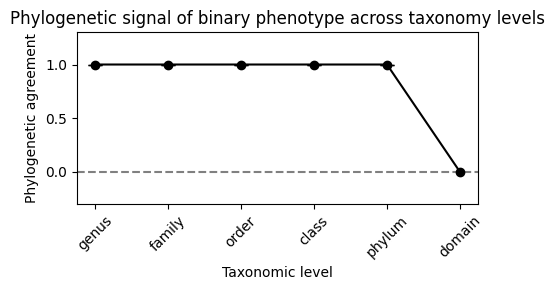

In [23]:
# Visualize the results

x = np.arange(len(levels))
means = [results[l]["mean"] for l in levels]
stds  = [results[l]["std"] for l in levels]

plt.figure(figsize=(5,3))

plt.errorbar(
    x, means,
    yerr=stds,
    marker='o',
    capsize=5,
    linestyle='-',
    c = "black"
)

plt.axhline(0, linestyle='--', c = "grey")

plt.xticks(x, levels, rotation=45)
plt.xlabel("Taxonomic level")
plt.ylabel("Phylogenetic agreement")
plt.title("Phylogenetic signal of binary phenotype across taxonomy levels")

plt.ylim(-0.3, 1.3)  

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIRECTORY}/phylogen_agreement_decay.svg", format="svg", bbox_inches='tight') #<-------save as pdf

plt.show()

#### 4.2. Predicting phenotypes based on the closes taxonomy group

In [25]:
from ete3 import Tree

# Load GTDB trees
tree_path_bact  = "../phylo_trees/bac120_r95.tree"  
tree_bact       = Tree(tree_path_bact, format=1, quoted_node_names=True)
nodes_bact      = {leaf.name: leaf for leaf in tree_bact.iter_leaves()}
leaf_names_bact = set(tree_bact.get_leaf_names())

tree_path_arch  = "../phylo_trees/ar122_r95.tree" 
tree_arch       = Tree(tree_path_arch, format=1, quoted_node_names=True)
nodes_arch      = {leaf.name: leaf for leaf in tree_arch.iter_leaves()}
leaf_names_arch = set(tree_arch.get_leaf_names())

#  Find the percentage of the annotated genomes that are not present in the tree genomes
count_not_present = 0
for genome in all_gen_access:
    if genome not in leaf_names_bact and genome not in leaf_names_arch:
        count_not_present += 1
count_not_present/len(set(all_gen_access)) 

0.01511879049676026

#### 4.2. Predicting phenotypes based on the closes taxonomy group

In [26]:
# Make phylogenetic prediction
from tqdm import tqdm
from utils.utils import one_split_phylogeny_prediction, evaluate_metrics

metrics_all_splits = defaultdict(int)
for split_id in tqdm(all_splits_dict.keys(), desc="Processing splits..."):

    # Get train and test data (only data annotations are needed)
    genome_accesion_train = all_splits_dict[split_id]["genome_accesion_train"]
    y_label_train         = all_splits_dict[split_id]["y_train"]

    genome_accesion_test = all_splits_dict[split_id]["genome_accesion_test"]
    y_label_test         = all_splits_dict[split_id]["y_test"]

    # Get the correct phenotype annotations for each genome accession 
    train_labels_dict = defaultdict(str)
    for idx, accesion in enumerate(genome_accesion_train):
        train_labels_dict[accesion] = y_label_train[idx].item()
    genome_accesion_train = set(genome_accesion_train)    

    test_labels_dict = defaultdict(str)
    for idx, accesion in enumerate(genome_accesion_test):
        test_labels_dict[accesion] = y_label_test[idx].item()
    
    # If it is not a corner case (random, domain), then find the predictions based on the majority phenotyclosest taxonomy group for each test genome
    if TAX_LEVEL not in {"random", "domain"}:    
        true_test_labels, predict_test_labels = one_split_phylogeny_prediction(genome_accesion_train, genome_accesion_test, train_labels_dict, test_labels_dict, nodes_bact, nodes_arch)
        metrics = evaluate_metrics(true_test_labels, predict_test_labels)
        metrics_all_splits[split_id] = metrics
        
    # For the random case, the prediction is based on the phylogenetically closest single genome
    elif TAX_LEVEL == "random":   
        true_test_labels = []
        predict_test_labels = []
        for genome_test_ind, genome_test_name in enumerate(genome_accesion_test):
            dist_min = float("inf")
            dist_label = None
            
            # Bacteria
            if genome_test_name in nodes_bact:
                for j, genome_train_name in enumerate(genome_accesion_train):
                    if genome_train_name in nodes_bact:
                        curr_dist = nodes_bact[genome_test_name].get_distance(nodes_bact[genome_train_name])
                        if curr_dist < dist_min:
                            dist_min = curr_dist
                            dist_label = train_labels_dict[genome_train_name]
                true_test_labels.append(test_labels_dict[genome_test_name])
                predict_test_labels.append(dist_label)                

            # Archaea
            if genome_test_name in nodes_arch:
                for j, genome_train_name in enumerate(genome_accesion_train):
                    if genome_train_name in nodes_arch:
                        curr_dist = nodes_arch[genome_test_name].get_distance(nodes_arch[genome_train_name])
                        if curr_dist < dist_min:
                            dist_min = curr_dist
                            dist_label = train_labels_dict[genome_train_name]
                true_test_labels.append(test_labels_dict[genome_test_name])
                predict_test_labels.append(dist_label)  
        
        metrics = evaluate_metrics(true_test_labels, predict_test_labels)
        metrics_all_splits[split_id] = metrics

    # For the domain case, the prediction of the test genomes in a domain is based on the majority phenotype in the other domain
    elif TAX_LEVEL == "domain":   
        predict_test_labels = [round(y_label_test.mean().item())]*len(y_label_test)
        metrics = evaluate_metrics(y_label_test, predict_test_labels)
        metrics_all_splits[split_id] = metrics

Processing splits...: 100%|████████████████████████████████████████████████████████████████████████████████████| 29/29 [06:08<00:00, 12.70s/it]


In [28]:
phylogen_accur_metrics = defaultdict(list)

for split_id in metrics_all_splits.keys():
    for metric in metrics_all_splits[split_id].keys():
        phylogen_accur_metrics[metric].append(metrics_all_splits[split_id][metric])

phylog_metrics_mean = defaultdict(str)
phylog_metrics_std  = defaultdict(str)

for metric in phylogen_accur_metrics.keys():
    phylog_metrics_mean[metric] = np.mean(phylogen_accur_metrics[metric])
    phylog_metrics_std[metric]  = np.std(phylogen_accur_metrics[metric])

In [29]:
metrics = {"phylog mean" : phylog_metrics_mean, "phylog std": phylog_metrics_std} 
df = pd.DataFrame(metrics)

# Optionally reorder the rows
df = df.reindex(['balanced_accuracy', 'precision', 'recall', 'f1', 'mcc', 'ece'])
df.to_csv(f"{OUTPUT_DIRECTORY}/phologeny_predict_metrics.csv")    
df

,phylog mean,phylog std
balanced_accuracy,0.609782,0.222280
precision,0.545405,0.243871
recall,0.609782,0.222280
f1,0.524682,0.233112
mcc,0.163685,0.418902
ece,NaN,NaN


## 5. Feature Selection

### 5.1 Markov Blankets

In [13]:
import json
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer

from feature_selection.feature_selection_utils import iamb

filename = f"{OUTPUT_DIRECTORY}/markov_boundaries.json"
all_markov_bound_dict = defaultdict(int)

#Define the number of the top N MI features to limit the feature space for the MB search
N = 500

# Read the file with MBs if it already exists
if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_markov_bound_dict = json.load(f)
else:
    for split_id in range(NUM_SPLITS_TO_READ):
        print(f"Processing split {split_id}")
        # Get the train data
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
        
        # Select top N MI features that will be used for the MB search
        mutual_info = mutual_info_classif(X_val_train.cpu(), y_label_train.cpu(), random_state=42)
        sorted_indices = np.argsort(mutual_info)[::-1] 
        top_N_indices = sorted_indices[:N]
        
        X_np = X_val_train.cpu().numpy()  
        y_np = y_label_train.cpu().numpy()  
    
        # Suppress only the specific warning from KBinsDiscretizer about small bin widths
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Bins whose width are too small")
            # Binarize the data
            X_np = (X_np > 0).astype(int)
            # Select the top N columns
            selected_columns = [f"{X_column_names[i]}" for i in range(X_np.shape[1])]
            X_filtered = pd.DataFrame(X_np, columns=np.array(selected_columns))#[selector.get_support()])
            X_filtered = X_filtered.iloc[:, top_N_indices]
            # Main MB algorithm              
            markov_boundary = iamb(X_filtered, y_np, alpha=0.01, verbose=False)
            
        all_markov_bound_dict[split_id] = markov_boundary

    with open(filename, "w") as f:
        json.dump(dict(all_markov_bound_dict), f, indent=2)

Reading the existing file...


In [14]:
# Find the frequencies of all MB features across all data splits
num_splits = len(all_markov_bound_dict.keys())

all_cogs = sorted(set(cog for lst in all_markov_bound_dict.values() for cog in lst))
presence_df = pd.DataFrame(0, index=all_cogs, columns=[f"Split_{i}" for i in all_markov_bound_dict])
for i, cogs in all_markov_bound_dict.items():
    presence_df.loc[cogs, f"Split_{i}"] = 1

# Add frequency column
presence_df["Frequency"] = presence_df.sum(axis=1)/num_splits

# Sort by frequency
presence_df_sorted = presence_df.sort_values("Frequency", ascending=False)


In [15]:
# Find the average MB lengths across all data splits
mb_lengths = []
all_markov_bound_dict_with_res = {}

for split_id in all_markov_bound_dict.keys():
    mb_lengths.append(len(all_markov_bound_dict[split_id]))
    markov_bound = all_markov_bound_dict[split_id]
    
    indices = [i for i, val in enumerate(X_column_names) if val in markov_bound]

    split_dict       = defaultdict(str)
    split_dict["MB"] = markov_bound[:]

    all_markov_bound_dict_with_res[split_id] = split_dict.copy()

print(f"Average MB length = {np.mean(mb_lengths)}; std = {np.std(mb_lengths)}")    

Average MB length = 4.633333333333334; std = 0.5467073155618908


In [16]:
# Save to CSV
dict_mb_stats = defaultdict(str)
dict_mb_stats["mb_length_aver"] = np.mean(mb_lengths)
dict_mb_stats["mb_length_std"]  = np.std(mb_lengths)

df = pd.DataFrame([dict_mb_stats])
df.to_csv(f"{OUTPUT_DIRECTORY}/mb_summary.csv", index=False)
df

,mb_length_aver,mb_length_std
0,4.633333,0.546707


In [17]:
# Find the average MB across all data splits

import math

aver_mb_len  = math.ceil(np.mean(mb_lengths))
aver_m_names = presence_df_sorted.index[:aver_mb_len].tolist()

with open(f"{OUTPUT_DIRECTORY}/aver_mb.txt", "w") as f:
    f.write(f"{aver_m_names}\n")
        
aver_m_names

['COG0795', 'COG0763', 'COG0854', 'COG5009', 'COG0751']

### 5.2 Check model performance on the Markov Blanket

In [18]:
# Calculate the baseline accuracies based on the test annotation vectors
test_accur_dict_splits_baseline = defaultdict(list)
for split_id in all_splits_dict.keys():
    X_val_train   = all_splits_dict[int(split_id)]["X_train"]
    y_label_train = all_splits_dict[int(split_id)]["y_train"]
    X_val_test    = all_splits_dict[int(split_id)]["X_test"]
    y_label_test  = all_splits_dict[int(split_id)]["y_test"]
    taxa_group_names_train = all_splits_dict[int(split_id)]["taxa_group_names_train"]
    
    N_tot = len(y_label_test)
    N_1   = sum(y_label_test).item()
    N_0   = N_tot - N_1
    fp    = tn = N_0 / 2
    tp    = fn = N_1 / 2
    
    if tp + fn > 0:
        pres   = tp / (tp + fp)
        recall = tp / (tp + fn)
        f1     = 2 * (pres * recall) / (pres + recall)
        
        # Accuracy
        accuracy = (tp + tn) / N_tot
        
        # Matthews correlation coefficient
        numerator = (tp * tn) - (fp * fn)
        denominator = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
        mcc = numerator / denominator if denominator != 0 else 0
        
        # Append to dict
        test_accur_dict_splits_baseline["accuracy"].append(accuracy)
        test_accur_dict_splits_baseline["precision"].append(pres)
        test_accur_dict_splits_baseline["recall"].append(recall)
        test_accur_dict_splits_baseline["f1"].append(f1)
        test_accur_dict_splits_baseline["roc_auc"].append(0)
        test_accur_dict_splits_baseline["mcc"].append(mcc)

test_accur_dict_splits_baseline_mean = defaultdict(float)
test_accur_dict_splits_baseline_std = defaultdict(float)
for accur_measure in test_accur_dict_splits_baseline.keys():
    
    #Baseline
    test_accur_dict_splits_baseline_mean[accur_measure]  = np.mean(test_accur_dict_splits_baseline[accur_measure])
    test_accur_dict_splits_baseline_std[accur_measure]  = np.std(test_accur_dict_splits_baseline[accur_measure])
metrics_baseline = {"test baseline mean": test_accur_dict_splits_baseline_mean, "test baseline std": test_accur_dict_splits_baseline_std} 
metrics_baseline        

{'test baseline mean': defaultdict(float,
             {'accuracy': np.float64(0.5),
              'precision': np.float64(0.3442629685548417),
              'recall': np.float64(0.5),
              'f1': np.float64(0.38351650184797315),
              'roc_auc': np.float64(0.0),
              'mcc': np.float64(0.0)}),
 'test baseline std': defaultdict(float,
             {'accuracy': np.float64(0.0),
              'precision': np.float64(0.16751571479470773),
              'recall': np.float64(0.0),
              'f1': np.float64(0.12460345540657196),
              'roc_auc': np.float64(0.0),
              'mcc': np.float64(0.0)})}

In [20]:
# Find the accuracies on different MB
from feature_selection.feature_selection_utils import find_accuracies_on_restricted_feat_space 

# MB on both train and test
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, "mb_train_test", DEVICE)
metrics_mb_train_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# MB on test only
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, "mb_zero_test", DEVICE)
metrics_mb_zero_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# Full feat set
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, "full", DEVICE)
metrics_full = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# (Full - MB) on both train and test
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, "no_mb_train_test", DEVICE)
metrics_no_mb_train_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

# (Full - MB) on test only
cv_accur_dict_mean, cv_accur_dict_std, test_accur_dict_mean, test_accur_dict_std = find_accuracies_on_restricted_feat_space(all_splits_dict, all_markov_bound_dict_with_res, X_column_names, "no_mb_test", DEVICE)
metrics_no_mb_test = {"cv mean" : cv_accur_dict_mean, "cv std": cv_accur_dict_std, "test mean": test_accur_dict_mean, "test std": test_accur_dict_std}

Processing splits...
Done!
Processing splits...
Done!
Processing splits...
Done!
Processing splits...
Done!
Processing splits...
Done!


In [23]:
# Create the output directory if doesn't exist
if not os.path.exists(f"{OUTPUT_DIRECTORY}/plots"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/plots")

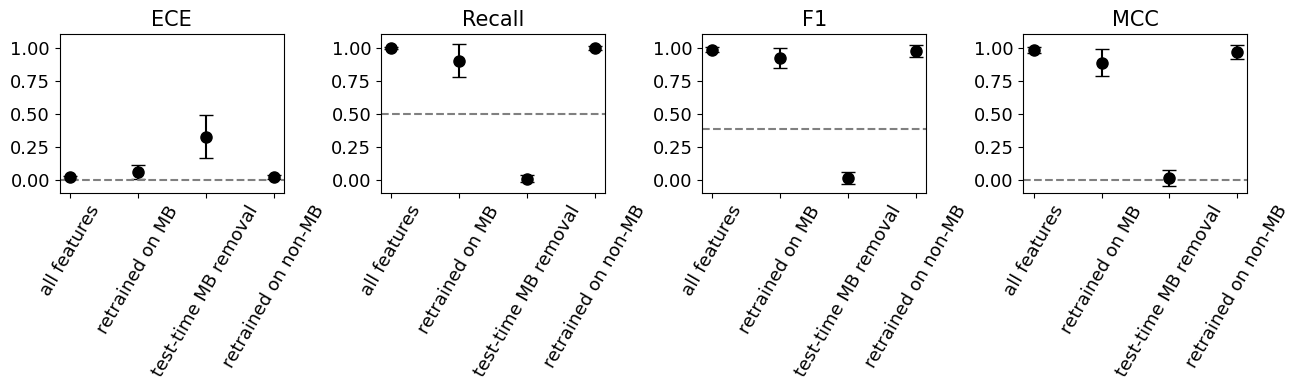

In [24]:
# Visualize the results

x = [0, 1, 2, 3]

xtick_labels = [
    'all features',
    'retrained on MB',
    'test-time MB removal',
    'retrained on non-MB'
]

models = [
    metrics_full,
    metrics_mb_train_test,
    metrics_mb_zero_test,
    metrics_no_mb_train_test
]

metrics_to_plot = [
    ("ece", "ECE"),
    ("recall", "Recall"),
    ("f1", "F1"),
    ("mcc", "MCC")
]

plt.figure(figsize=(13, 4))

for i, (metric, title) in enumerate(metrics_to_plot, start=1):

    plt.subplot(1, 4, i)

    for j, model_metrics in enumerate(models):
        plt.errorbar(
            [j],
            model_metrics['test mean'][metric],
            yerr=model_metrics['test std'][metric],
            fmt='o',
            capsize=5,
            markersize=8,
            color='black'
        )

    plt.axhline(
        y=metrics_baseline['test baseline mean'][metric],
        color='grey',
        linestyle='--',
        label='Baseline'
    )

    plt.xticks(ticks=x, labels=xtick_labels, rotation=60, fontsize=13)
    plt.yticks(fontsize=13)
    plt.ylim(-0.1, 1.1)
    plt.title(title, fontsize=15)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/performance_on_mb_{TAX_LEVEL}_taxlevel.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

### 5.3 SHAP values

In [26]:
# Create SHAP output directories if they do not exist
if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_removal")

if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/feat_add")    

if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models_shap/all_feat")  

In [27]:
from feature_selection.feature_selection_utils import shap_features

filename = f"{OUTPUT_DIRECTORY}/shap_list.json"
all_shap_lists_dict = defaultdict(int)

# If the SHAP file exist - read it
if os.path.isfile(filename):
    print("Reading the existing file...")
    with open(filename, "rb") as f:
        all_shap_lists_dict = json.load(f)
# Otherwise, find and save SHAP lists for each data split
else:
    for split_id in all_splits_dict.keys():
        print(f"Processing split {split_id}")
        X_val_train =  all_splits_dict[split_id]["X_train"]
        y_label_train =  all_splits_dict[split_id]["y_train"]
        X_column_names =  all_splits_dict[split_id]["feature_names"]

        sorted_cog_idx_by_shap, sorted_shap, sorted_names, shap_vals  = shap_features(X_val_train.int().cpu(), y_label_train.cpu(), X_column_names, device) 

        all_shap_lists_dict[split_id] = sorted_names[:]#[:N]

    with open(filename, "w") as f:
        json.dump(dict(all_shap_lists_dict), f, indent=2)

Reading the existing file...


In [28]:
from feature_selection.feature_selection_utils import shap_curves_file

In [33]:
# Find accuracies for the feature list where the features are gradually added wrt their SHAP values (starting from the most important ones): re-trained without the features

feat_step = 10                    # removel step size
feat_removal = False              # flag for weather are gradually added (False), or removed (True)
train_test_feat_apply_flag = True # weather the feature removal strategy is applied to the train+test (True) only or test only data (False)
fully_remove_feat_info = True    # wheather the information about the absent features is fully eraised, i.e. Nan (True), or just = 0 (False)
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_add_feat_train_test.pkl"

accuracy_curves_all_splits_add_feat_train_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict, fully_remove_feat_info = fully_remove_feat_info)

Loaded existing results from ../data_diderm/outputs/phylum/accuracy_curves_all_splits_add_feat_train_test.pkl


In [35]:
feat_step = 10
feat_removal = False
train_test_feat_apply_flag = False
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_add_feat_test.pkl"

accuracy_curves_all_splits_add_feat_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

Loaded existing results from ../data_diderm/outputs/phylum/accuracy_curves_all_splits_add_feat_test.pkl


In [36]:
feat_step = 10
feat_removal = True
train_test_feat_apply_flag = True
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_train_test.pkl"

accuracy_curves_all_splits_rem_feat_train_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

Loaded existing results from ../data_diderm/outputs/phylum/accuracy_curves_all_splits_rem_feat_train_test.pkl


In [37]:
feat_step = 10
feat_removal = True
train_test_feat_apply_flag = False
filename = f"{OUTPUT_DIRECTORY}/accuracy_curves_all_splits_rem_feat_test.pkl"

accuracy_curves_all_splits_rem_feat_test = shap_curves_file(train_test_feat_apply_flag, filename, feat_step, feat_removal, all_splits_dict)

Loaded existing results from ../data_diderm/outputs/phylum/accuracy_curves_all_splits_rem_feat_test.pkl


Balanced accuracy: Mean index = 1.66, Std = 1.82
Recall: Mean index = 1.34, Std = 1.82
F1: Mean index = 2.17, Std = 1.97
MCC: Mean index = 2.38, Std = 1.94


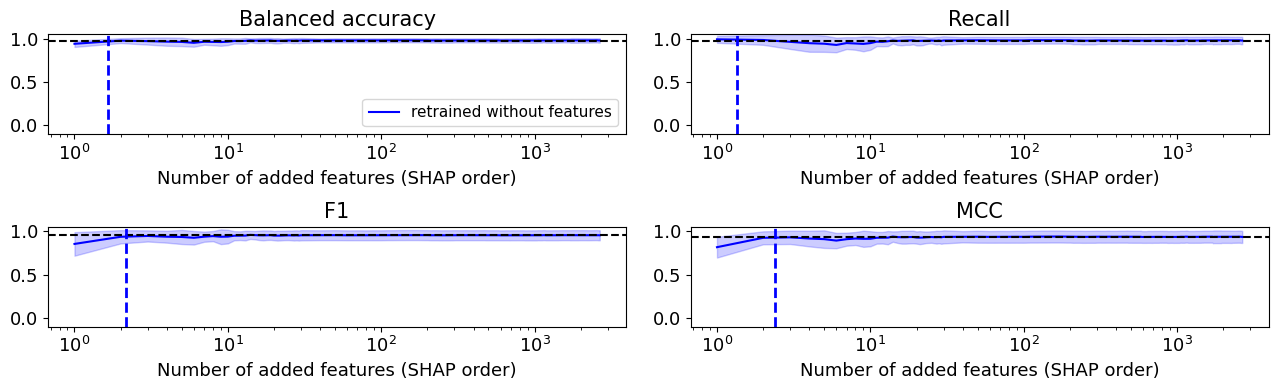

In [38]:
# Vusualize the case of gradually adding features

from feature_selection.feature_selection_utils import (
    accur_curves,
    find_mean_std_curve,
    find_increas_curve_index,
)

# Extract curves
(
    bal_accur_curve_train_test,
    recall_curves_train_test,
    mcc_curv_train_test,
    f1_curves_train_test,
    num_feat_train_test,
) = accur_curves(accuracy_curves_all_splits_add_feat_train_test)

x = num_feat_train_test[0]

metrics = [
    ("Balanced accuracy", bal_accur_curve_train_test),
    ("Recall", recall_curves_train_test),
    ("F1", f1_curves_train_test),
    ("MCC", mcc_curv_train_test),
]

plt.figure(figsize=(13, 4))

for subplot_idx, (metric_name, curves) in enumerate(metrics, start=1):

    plt.subplot(2, 2, subplot_idx)

    # Find the number of features at which the curve reaches the threshold
    indices = [
        find_increas_curve_index(curve, x, thresh_percent=0.95)
        for curve in curves
    ]

    print(
        f"{metric_name}: "
        f"Mean index = {np.mean(indices):.2f}, "
        f"Std = {np.std(indices):.2f}"
    )

    mean_curve, std_curve = find_mean_std_curve(curves)

    plt.plot(
        x,
        mean_curve,
        color="blue",
        label="retrained without features" if subplot_idx == 1 else None,
    )

    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.2,
        color="blue",
    )

    # Full-feature performance
    plt.axhline(
        y=mean_curve[-1],
        color="black",
        linestyle="--",
    )

    # 95% threshold location
    mean_index = np.mean(indices)
    plt.axvline(
        mean_index,
        color="blue",
        linestyle="--",
        linewidth=2,
    )

    plt.xlabel("Number of added features (SHAP order)", fontsize=13)
    plt.title(metric_name, fontsize=15)

    plt.ylim([-0.1, 1.05])
    plt.xscale("log")

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    if subplot_idx == 1:
        plt.legend(fontsize=11)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/shap_order_feature_add_{TAX_LEVEL}_taxlevel.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()

Balanced accuracy (train+test): Mean=1242.07, Std=768.41
Balanced accuracy (test only): Mean=2.31, Std=0.46
___________________
Recall (train+test): Mean=1186.41, Std=890.02
Recall (test only): Mean=17.00, Std=6.81
___________________
F1 (train+test): Mean=949.86, Std=743.59
F1 (test only): Mean=2.48, Std=1.19
___________________
MCC (train+test): Mean=720.52, Std=718.36
MCC train+test threshold: 720.52 ± 718.36
MCC (test only): Mean=2.03, Std=0.18
MCC test-only threshold: 2.03 ± 0.18
___________________


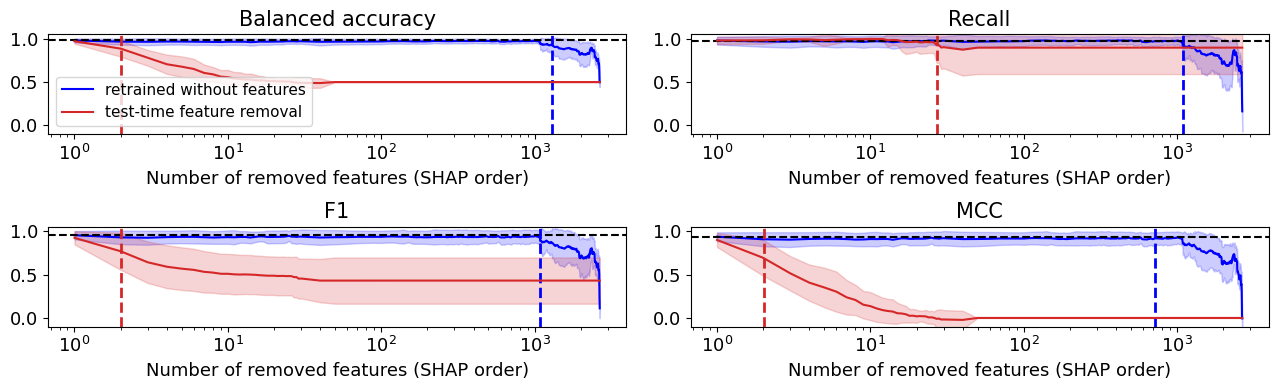

In [39]:
# Vusualize the case of gradually removing features

from feature_selection.feature_selection_utils import (
    find_mean_std_index_for_curves,
    find_decreas_curve_index,
    find_mean_std_curve,
)

(
    bal_accur_curve_train_test,
    recall_curves_train_test,
    mcc_curves_train_test,
    f1_curves_train_test,
    num_feat_train_test,
) = accur_curves(accuracy_curves_all_splits_rem_feat_train_test)

(
    bal_accur_curve_test,
    recall_curves_test,
    mcc_curves_test,
    f1_curves_test,
    num_feat_test,
) = accur_curves(accuracy_curves_all_splits_rem_feat_test)

x_train_test = num_feat_train_test[0]
x_test = num_feat_test[0]

metrics = [
    ("Balanced accuracy", bal_accur_curve_train_test, bal_accur_curve_test),
    ("Recall",            recall_curves_train_test,   recall_curves_test),
    ("F1",                f1_curves_train_test,       f1_curves_test),
    ("MCC",               mcc_curves_train_test,      mcc_curves_test),
]

plt.figure(figsize=(13, 4))

for subplot_idx, (metric_name, curves_train, curves_test) in enumerate(metrics, start=1):

    plt.subplot(2, 2, subplot_idx)

    #Train + test removal
    mean_train, std_train = find_mean_std_curve(curves_train)

    plt.plot(
        x_train_test,
        mean_train,
        color="blue",
        label="retrained without features" if subplot_idx == 1 else None,
    )

    plt.fill_between(
        x_train_test,
        mean_train - std_train,
        mean_train + std_train,
        color="blue",
        alpha=0.2,
    )

    plt.axhline(
        y=mean_train[0],
        color="black",
        linestyle="--",
    )

    train_indices = find_mean_std_index_for_curves(
        curves_train,
        x_train_test,
    )

    print(
        f"{metric_name} (train+test): "
        f"Mean={np.mean(train_indices):.2f}, "
        f"Std={np.std(train_indices):.2f}"
    )

    # MCC uses stability filtering
    if metric_name == "MCC":
        valid = [
            find_decreas_curve_index(
                curve,
                x_train_test,
                thresh_percent=0.95,
                stability=5,
            )
            for curve in curves_train
            if curve[0] > 0.5
        ]
        train_threshold = np.mean(valid)

        print(
            f"MCC train+test threshold: "
            f"{train_threshold:.2f} ± {np.std(valid):.2f}"
        )
    else:
        train_threshold = find_decreas_curve_index(
            mean_train,
            x_train_test,
            thresh_percent=0.95,
        )

    plt.axvline(
        train_threshold,
        color="blue",
        linestyle="--",
        linewidth=2,
    )

    # Test-only removal
    mean_test, std_test = find_mean_std_curve(curves_test)

    plt.plot(
        x_test,
        mean_test,
        color="tab:red",
        label="test-time feature removal" if subplot_idx == 1 else None,
    )

    plt.fill_between(
        x_test,
        mean_test - std_test,
        mean_test + std_test,
        color="tab:red",
        alpha=0.2,
    )

    test_indices = find_mean_std_index_for_curves(
        curves_test,
        x_test,
    )

    print(
        f"{metric_name} (test only): "
        f"Mean={np.mean(test_indices):.2f}, "
        f"Std={np.std(test_indices):.2f}"
    )

    if metric_name == "MCC":
        valid = [
            find_decreas_curve_index(
                curve,
                x_test,
                thresh_percent=0.95,
                stability=5,
            )
            for curve in curves_test
            if curve[0] > 0.5
        ]
        test_threshold = np.mean(valid)

        print(
            f"MCC test-only threshold: "
            f"{test_threshold:.2f} ± {np.std(valid):.2f}"
        )
    else:
        test_threshold = find_decreas_curve_index(
            mean_test,
            x_test,
            thresh_percent=0.95,
        )

    plt.axvline(
        test_threshold,
        color="tab:red",
        linestyle="--",
        linewidth=2,
    )

    plt.title(metric_name, fontsize=15)
    plt.xlabel("Number of removed features (SHAP order)", fontsize=13)

    plt.ylim([-0.1, 1.05])
    plt.xscale("log")

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    if subplot_idx == 1:
        plt.legend(fontsize=11)

    print("___________________")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/shap_order_feature_removal_{TAX_LEVEL}_taxlevel_fully_rem_info.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()
